# Transaction Category Model Evaluation
This notebook evaluates the category classifier using a train/test split from labeled transactions in the DB.

In [1]:
import os
import django

os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'budget_project.settings')
# Jupyter runs an event loop; allow Django ORM access in this notebook context.
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')
django.setup()

print('Django initialized')

Django initialized


In [2]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

from budget.category_classifier import TransactionCategoryClassifier

In [3]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
THRESHOLDS = [0.30, 0.45, 0.60, 0.75]

clf = TransactionCategoryClassifier()
features, labels = clf.build_dataset_from_db()
label_counts = Counter(labels)

print(f'Rows: {len(features)}')
print(f'Categories: {len(label_counts)}')
print('Top categories:', label_counts.most_common(10))

Rows: 1300
Categories: 15
Top categories: [('Grocery', 478), ('Eat-outs', 262), ('Travel', 113), ('Household', 98), ('Sport/Health', 80), ('Rent+Utilities', 55), ('Yaki/Nori', 47), ('Home', 39), ('Transportation', 39), ('Work Income', 33)]


In [4]:
label_counts

Counter({'Grocery': 478,
         'Eat-outs': 262,
         'Travel': 113,
         'Household': 98,
         'Sport/Health': 80,
         'Rent+Utilities': 55,
         'Yaki/Nori': 47,
         'Home': 39,
         'Transportation': 39,
         'Work Income': 33,
         'Subscriptions': 27,
         'Cash': 10,
         'Other Income': 8,
         'Savings': 7,
         'From Savings': 4})

In [5]:
if len(features) < clf.min_samples:
    raise ValueError(f'Need at least {clf.min_samples} labeled rows, found {len(features)}')
if len(label_counts) < clf.min_classes:
    raise ValueError('Need at least 2 categories for evaluation')

stratify = labels if min(label_counts.values()) >= 2 else None
x_train, x_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify,
)

# Convert dicts to DataFrames for sklearn pipeline
x_train_df = pd.DataFrame(x_train)
x_test_df = pd.DataFrame(x_test)

model = clf.create_pipeline()
model.fit(x_train_df, y_train)

y_pred = model.predict(x_test_df)
y_proba = model.predict_proba(x_test_df)
max_conf = y_proba.max(axis=1)

print(f'Train rows: {len(x_train)} | Test rows: {len(x_test)}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Macro F1: {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Weighted F1: {f1_score(y_test, y_pred, average="weighted"):.4f}')

Train rows: 1040 | Test rows: 260
Accuracy: 0.8346
Macro F1: 0.6667
Weighted F1: 0.8247


In [19]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

                precision    recall  f1-score   support

          Cash     0.0000    0.0000    0.0000         2
      Eat-outs     0.7377    0.8654    0.7965        52
  From Savings     0.0000    0.0000    0.0000         1
       Grocery     0.9286    0.9579    0.9430        95
          Home     1.0000    0.1250    0.2222         8
     Household     1.0000    0.8000    0.8889        20
  Other Income     0.0000    0.0000    0.0000         2
Rent+Utilities     1.0000    1.0000    1.0000        11
       Savings     0.0000    0.0000    0.0000         1
  Sport/Health     0.9412    1.0000    0.9697        16
 Subscriptions     1.0000    0.8000    0.8889         5
Transportation     0.8571    0.7500    0.8000         8
        Travel     0.9130    0.9130    0.9130        23
   Work Income     0.7000    1.0000    0.8235         7
     Yaki/Nori     0.7500    1.0000    0.8571         9

      accuracy                         0.8731       260
     macro avg     0.6552    0.6141    0.6069 

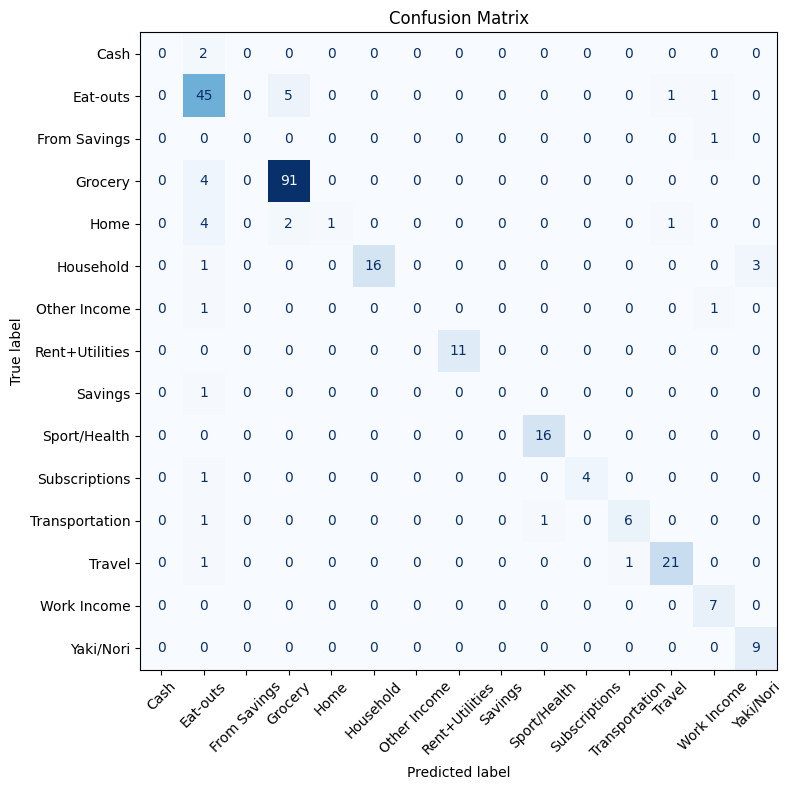

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
    cmap='Blues',
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [21]:
results = []
for threshold in THRESHOLDS:
    idx = np.where(max_conf >= threshold)[0]
    coverage = len(idx) / len(y_test)

    if len(idx) == 0:
        results.append((threshold, coverage, 0, np.nan, np.nan, np.nan))
        continue

    yt = [y_test[i] for i in idx]
    yp = [y_pred[i] for i in idx]
    p, r, f1, _ = precision_recall_fscore_support(
        yt, yp, average='macro', zero_division=0
    )
    results.append((threshold, coverage, len(idx), p, r, f1))

for threshold, coverage, accepted, p, r, f1 in results:
    print(
        f't={threshold:.2f} | coverage={coverage:.3f} | accepted={accepted} | ' \
        f'precision_macro={p:.3f} recall_macro={r:.3f} f1_macro={f1:.3f}'
    )

t=0.30 | coverage=0.935 | accepted=243 | precision_macro=0.711 recall_macro=0.739 f1_macro=0.722
t=0.45 | coverage=0.827 | accepted=215 | precision_macro=0.814 recall_macro=0.824 f1_macro=0.819
t=0.60 | coverage=0.746 | accepted=194 | precision_macro=0.992 recall_macro=0.992 f1_macro=0.992
t=0.75 | coverage=0.565 | accepted=147 | precision_macro=0.995 recall_macro=0.998 f1_macro=0.997


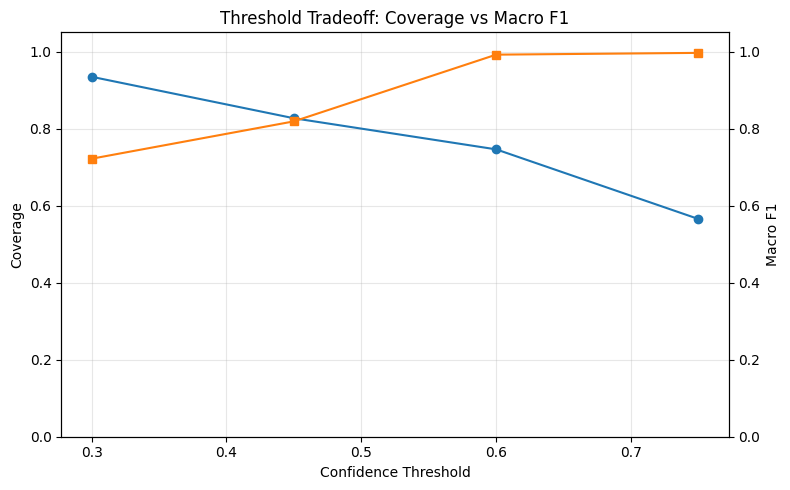

In [22]:
thresholds = [r[0] for r in results]
coverage = [r[1] for r in results]
f1s = [r[5] for r in results]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(thresholds, coverage, marker='o', label='Coverage')
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Coverage')
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(thresholds, f1s, marker='s', color='tab:orange', label='Macro F1 (accepted)')
ax2.set_ylabel('Macro F1')
ax2.set_ylim(0, 1.05)

ax1.set_title('Threshold Tradeoff: Coverage vs Macro F1')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()